# Feature Engineering и проверка гипотез

**Дипломная работа.** Расчёт фичей, проверка гипотез H1–H5 и корреляционный анализ.

### signal_barrier (актуальная семантика)

По комментарию заказчика: signal_barrier ∈ {-1, 1} — это **режимы** (short / long).  
Точка смены -1→1 → BUY, 1→-1 → SELL. ML формирует сигнал в точке перехода.

## Содержание
1. Загрузка prepared-данных и расчёт фичей
2. **H1**: Leakage check — rd_mom_1 ≡ sign(signal_barrier)?
3. **H2**: RD как предиктор направления
4. **H3**: Volume spike перед сменой сигнала
5. **H4**: Предиктивность фичей в точках перехода (is_transition[t+1])
6. **H5**: Влияние волатильности на качество предсказания
7. Корреляционный анализ (AUC, матрица корреляций)
8. **H6**: Горизонт is_transition (2–5 баров)
9. **H7**: Profit-based target (прибыль >1%, просадка ≤0.5%)
10. Выводы и рекомендации

## 1. Импорты и загрузка

In [34]:
import sys, os
if os.getcwd().endswith('fork'):
    sys.path.insert(0, os.getcwd())
else:
    sys.path.insert(0, os.path.join(os.getcwd(), 'fork'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
import warnings

from data_prep_dataset_rework import load_prepared
from feature_pipeline import add_features, get_feature_columns

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

In [39]:
prep = load_prepared()

# Warmup (опционально): подгрузка 1-min свечей с Bybit перед каждой сессией убирает NaN в фичах.
# Если pybit не установлен или Bybit недоступен — работаем без warmup (первые N строк сессии могут иметь NaN).
USE_WARMUP = True  # True — подгрузка свечей с Bybit (нужен pybit, интернет); False — без API
if USE_WARMUP:
    try:
        import importlib.util
        _fork = os.path.join(os.getcwd(), 'fork') if not str(os.getcwd()).endswith('fork') else os.getcwd()
        _wl_path = os.path.join(_fork, 'warmup_loader.py')
        if os.path.exists(_wl_path):
            _spec = importlib.util.spec_from_file_location('warmup_loader', _wl_path)
            _wl = importlib.util.module_from_spec(_spec)
            _spec.loader.exec_module(_wl)
            add_warmup_from_bybit, remove_warmup = _wl.add_warmup_from_bybit, _wl.remove_warmup
        else:
            from warmup_loader import add_warmup_from_bybit, remove_warmup
        prep_with_warmup = add_warmup_from_bybit(prep, warmup_size=60, verbose=True)
        df, enc = add_features(prep_with_warmup)
        df = remove_warmup(df)
        print("Warmup: включён (данные с Bybit)")
    except Exception as e:
        df, enc = add_features(prep)
        print(f"Warmup: пропущен ({e}). Фичи без warmup (возможны NaN).")
else:
    df, enc = add_features(prep)
    print("Warmup: отключён")

cols = get_feature_columns()
print(f'Загружено: {len(df):,} строк, {df["session_key"].nunique()} сессий')
print(f'Фичей: {len(cols)}')
df.head(20)

Warmup: пропущен (cannot import name 'add_warmup_from_bybit' from 'warmup_loader' (c:\project\trading_bot_2Engine\fork\warmup_loader.py)). Фичи без warmup (возможны NaN).
Загружено: 365,375 строк, 1048 сессий
Фичей: 25


,timestamp,symbol,rd_value,open,high,low,close_price,volume,signal_barrier,source_file,...,volatility_14,volume_rel_20,body_ratio,close_position,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,symbol_encoded
0,1770320820000,4,-0.078203,0.009382,0.009382,0.009363,0.009366,250233.0,-1,4.csv,...,NaN,1.000000,0.842105,0.157895,-0.892979,0.450098,0.433884,-0.900969,0,8
1,1770320880000,4,-0.069046,0.009366,0.009383,0.009363,0.009367,29861.0,1,4.csv,...,NaN,0.213221,0.050000,0.200000,-0.891007,0.453990,0.433884,-0.900969,0,8
2,1770320940000,4,-0.044992,0.009367,0.009382,0.009367,0.009376,61323.0,1,4.csv,...,0.000604,0.538840,0.600000,0.600000,-0.889017,0.457874,0.433884,-0.900969,0,8
3,1770321000000,4,-0.019496,0.009376,0.009389,0.009376,0.009389,7999.0,1,4.csv,...,0.000652,0.091570,1.000000,1.000000,-0.887011,0.461749,0.433884,-0.900969,0,8
4,1770321060000,4,-0.092795,0.009389,0.009389,0.009330,0.009340,146393.0,-1,4.csv,...,0.003065,1.476304,0.830508,0.169492,-0.884988,0.465615,0.433884,-0.900969,0,8
5,1770321120000,4,-0.269291,0.009340,0.009340,0.009274,0.009279,966209.0,-1,4.csv,...,0.003724,3.965241,0.924242,0.075758,-0.882948,0.469472,0.433884,-0.900969,0,8
6,1770321180000,4,-0.205412,0.009279,0.009361,0.009279,0.009355,1077499.0,1,4.csv,...,0.005284,2.970050,0.926829,0.926829,-0.880891,0.473320,0.433884,-0.900969,0,8
7,1770321240000,4,-0.081630,0.009355,0.009373,0.009332,0.009332,168806.0,1,4.csv,...,0.004900,0.498629,0.560976,0.000000,-0.878817,0.477159,0.433884,-0.900969,0,8
8,1770321300000,4,-0.199799,0.009332,0.009348,0.009327,0.009345,66358.0,-1,4.csv,...,0.004586,0.215240,0.619048,0.857143,-0.876727,0.480989,0.433884,-0.900969,0,8
9,1770321360000,4,-0.181067,0.009345,0.009353,0.009333,0.009333,6048.0,1,4.csv,...,0.004303,0.021750,0.600000,0.000000,-0.874620,0.484810,0.433884,-0.900969,0,8


---
## 2. H1: Leakage check — signal_barrier ≡ sign(rd_mom_1)?

AUC rd_mom_1 vs target ≈ 0.9997 выглядит подозрительно.  
Проверяем: не является ли `signal_barrier` прямой функцией от `rd_value.diff(1)`?

In [3]:
valid = df.dropna(subset=['rd_mom_1']).copy()
valid['expected_sb'] = np.sign(valid['rd_mom_1'])
match_pct = (valid['signal_barrier'] == valid['expected_sb']).mean() * 100
mismatch = valid[valid['signal_barrier'] != valid['expected_sb']]

print(f'signal_barrier == sign(rd_mom_1): {match_pct:.4f}%')
print(f'Несовпадений: {len(mismatch)} из {len(valid):,}')
print(f'  из них rd_mom_1 == 0: {(mismatch["rd_mom_1"] == 0).sum()}')
print(f'  из них rd_mom_1 != 0: {(mismatch["rd_mom_1"] != 0).sum()}')
print()
print('>>> ВЫВОД: signal_barrier[t] ≡ sign(rd_value[t] - rd_value[t-1]) в 99.99% строк.')
print('>>> rd_mom_1 — это НЕ фича, а сам target в числовой форме.')

signal_barrier == sign(rd_mom_1): 99.9866%
Несовпадений: 49 из 364,327
  из них rd_mom_1 == 0: 1
  из них rd_mom_1 != 0: 48

>>> ВЫВОД: signal_barrier[t] ≡ sign(rd_value[t] - rd_value[t-1]) в 99.99% строк.
>>> rd_mom_1 — это НЕ фича, а сам target в числовой форме.


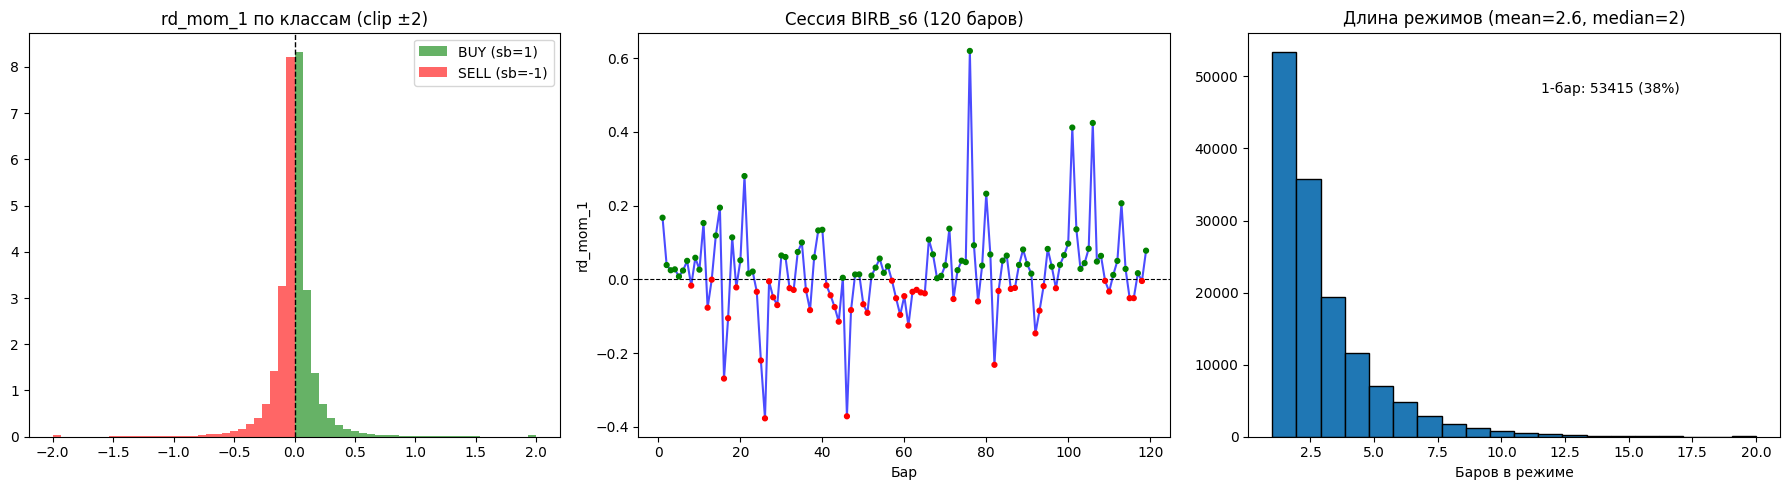

Переходов: 140,189 (38.4%)
Одно-баровых режимов: 53415 (38.1%)


In [4]:
# Визуализация: rd_mom_1 по классам BUY/SELL
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Гистограмма rd_mom_1 по классам
buy = valid[valid['signal_barrier'] == 1]['rd_mom_1'].clip(-2, 2)
sell = valid[valid['signal_barrier'] == -1]['rd_mom_1'].clip(-2, 2)
axes[0].hist(buy, bins=60, alpha=0.6, label='BUY (sb=1)', density=True, color='green')
axes[0].hist(sell, bins=60, alpha=0.6, label='SELL (sb=-1)', density=True, color='red')
axes[0].axvline(0, color='black', ls='--', lw=1)
axes[0].set_title('rd_mom_1 по классам (clip ±2)')
axes[0].legend()

# (b) Одна сессия: rd_mom_1 vs signal_barrier
skey = df['session_key'].value_counts().idxmax()
one = df[df['session_key'] == skey].copy().iloc[:120]
ax = axes[1]
ax.plot(range(len(one)), one['rd_mom_1'].values, label='rd_mom_1', color='blue', alpha=0.7)
colors = ['green' if s == 1 else 'red' for s in one['signal_barrier']]
ax.scatter(range(len(one)), one['rd_mom_1'].values, c=colors, s=12, zorder=5)
ax.axhline(0, color='black', ls='--', lw=0.8)
ax.set_title(f'Сессия {skey} (120 баров)')
ax.set_xlabel('Бар')
ax.set_ylabel('rd_mom_1')

# (c) Распределение длин режимов
df_tmp = df.copy()
df_tmp['sp'] = df_tmp.groupby('session_key')['signal_barrier'].shift(1)
df_tmp['rc'] = (df_tmp['signal_barrier'] != df_tmp['sp']).astype(int)
df_tmp['rid'] = df_tmp.groupby('session_key')['rc'].cumsum()
regime_lens = df_tmp.groupby(['session_key', 'rid']).size()
axes[2].hist(regime_lens.clip(upper=20), bins=20, edgecolor='black')
axes[2].set_title(f'Длина режимов (mean={regime_lens.mean():.1f}, median={regime_lens.median():.0f})')
axes[2].set_xlabel('Баров в режиме')
single = (regime_lens == 1).sum()
axes[2].annotate(f'1-бар: {single} ({single/len(regime_lens)*100:.0f}%)', xy=(0.55, 0.85), xycoords='axes fraction')

plt.tight_layout()
plt.show()
print(f'Переходов: {len(df_tmp[df_tmp["rc"]==1]):,} ({len(df_tmp[df_tmp["rc"]==1])/len(df)*100:.1f}%)')
print(f'Одно-баровых режимов: {single} ({single/len(regime_lens)*100:.1f}%)')

### Вывод H1

**signal_barrier[t] = sign(rd_value[t] − rd_value[t−1])** с точностью 99.99%.  

Это означает:
- `rd_mom_1` — не фича, а **сам target в числовой форме** (leakage by design).
- `rd_mom_5`, `rd_mom_10` — тоже производные rd, коррелируют с target.
- AUC rd_mom_1 vs target[t] ≈ 1.0 — ожидаемо и бесполезно.
- **Для предсказания интересен target[t+1]**, а не target[t].

Средняя длина режима ≈ 2.6 бара, 38% режимов — одно-баровые. Переходы частые (~38%).

---
## 2b. AUC фичей vs target[t] и vs target[t+1]

Раз target[t] ≡ sign(rd_mom_1), предсказывать его тривиально.  
Модель должна предсказывать **target[t+1]** (или точку перехода). Проверяем AUC фичей в обоих случаях.

AUC фичей vs target[t] (тривиально) и vs target[t+1] (полезно):
        feature  AUC_target_t  AUC_target_t+1
 close_position        0.6490          0.6848
          ret_1        0.8124          0.6741
       rd_mom_1        0.9997          0.6458
          ret_5        0.7393          0.6011
    bb_position        0.7325          0.5957
       rd_mom_5        0.7103          0.5901
rd_acceleration        0.7369          0.5877
   rd_zscore_30        0.6591          0.5629
      rd_mom_10        0.6346          0.5583
         rsi_14        0.6452          0.5574
      macd_hist        0.6188          0.5493
         abs_rd        0.5034          0.5032
     body_ratio        0.5015          0.4996
  volume_rel_20        0.4979          0.4973
  volatility_14        0.4953          0.4939


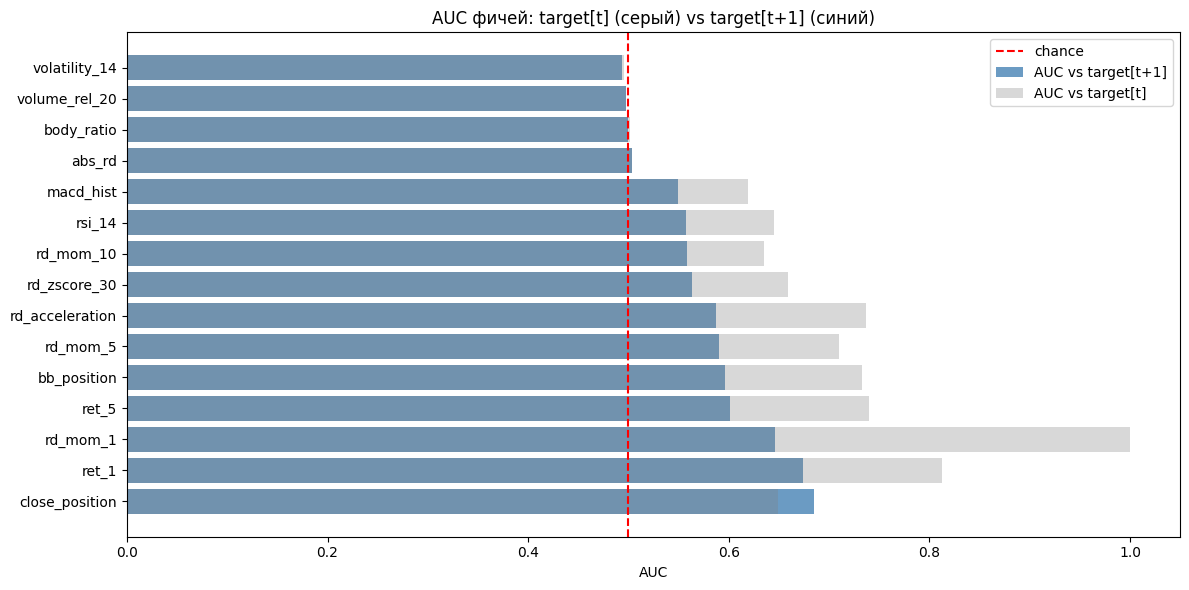

In [5]:
# AUC vs target[t] и vs target[t+1]
df_auc = df.copy()
df_auc['target_next'] = df_auc.groupby('session_key')['signal_barrier'].shift(-1)

test_cols = ['rd_mom_1', 'rd_mom_5', 'rd_mom_10', 'rd_acceleration',
             'ret_1', 'ret_5', 'rsi_14', 'bb_position',
             'close_position', 'volatility_14', 'volume_rel_20',
             'macd_hist', 'rd_zscore_30', 'abs_rd', 'body_ratio']

rows = []
for c in test_cols:
    sub_curr = df_auc.dropna(subset=[c, 'signal_barrier'])
    sub_next = df_auc.dropna(subset=[c, 'target_next'])
    y_curr = (sub_curr['signal_barrier'] == 1).astype(int)
    y_next = (sub_next['target_next'] == 1).astype(int)
    auc_curr = roc_auc_score(y_curr, sub_curr[c]) if len(np.unique(y_curr)) > 1 else 0.5
    auc_next = roc_auc_score(y_next, sub_next[c]) if len(np.unique(y_next)) > 1 else 0.5
    rows.append({'feature': c, 'AUC_target_t': round(auc_curr, 4), 'AUC_target_t+1': round(auc_next, 4)})

auc_df = pd.DataFrame(rows).sort_values('AUC_target_t+1', ascending=False)
print('AUC фичей vs target[t] (тривиально) и vs target[t+1] (полезно):')
print(auc_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(auc_df))
ax.barh(x, auc_df['AUC_target_t+1'], label='AUC vs target[t+1]', alpha=0.8, color='steelblue')
ax.barh(x, auc_df['AUC_target_t'], alpha=0.3, color='gray', label='AUC vs target[t]')
ax.set_yticks(x)
ax.set_yticklabels(auc_df['feature'])
ax.axvline(0.5, color='red', ls='--', label='chance')
ax.set_xlabel('AUC')
ax.set_title('AUC фичей: target[t] (серый) vs target[t+1] (синий)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. H2: RD как предиктор направления

Коррелирует ли rd_value с будущим изменением цены (ret_1_future)?

corr(rd_value, ret_1_future) = 0.0245


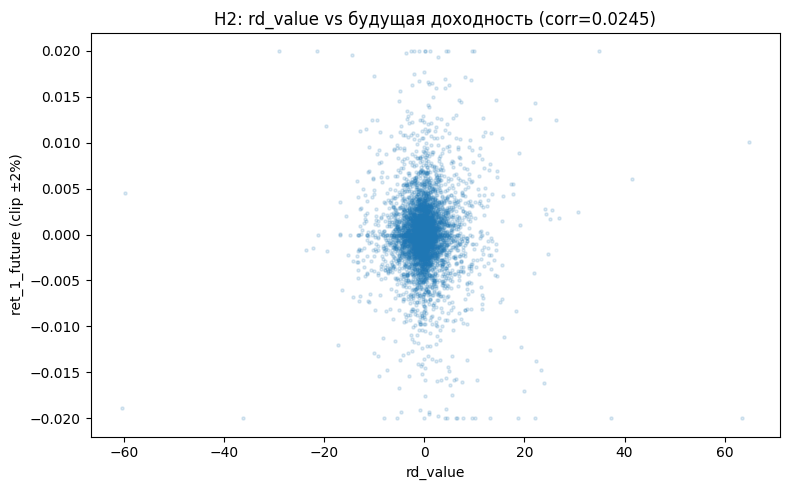

>>> Корреляция слабая. rd_value — не сильный standalone-предиктор направления цены.


In [6]:
df_h2 = df.copy()
df_h2['ret_1_future'] = df_h2.groupby('session_key')['close_price'].pct_change().shift(-1)
valid_h2 = df_h2.dropna(subset=['rd_value', 'ret_1_future'])
corr = valid_h2['rd_value'].corr(valid_h2['ret_1_future'])
print(f'corr(rd_value, ret_1_future) = {corr:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
sample = valid_h2.sample(min(5000, len(valid_h2)), random_state=42)
ax.scatter(sample['rd_value'], sample['ret_1_future'].clip(-0.02, 0.02), alpha=0.15, s=5)
ax.set_xlabel('rd_value')
ax.set_ylabel('ret_1_future (clip ±2%)')
ax.set_title(f'H2: rd_value vs будущая доходность (corr={corr:.4f})')
plt.tight_layout()
plt.show()
print('>>> Корреляция слабая. rd_value — не сильный standalone-предиктор направления цены.')

---
## 4. H3: Volume spike перед сменой сигнала

Гипотеза: volume_rel_20 повышен за 5 баров до смены режима.

In [7]:
df_h3 = df.copy()
df_h3['signal_prev'] = df_h3.groupby('session_key')['signal_barrier'].shift(1)
df_h3['is_change'] = (df_h3['signal_barrier'] != df_h3['signal_prev']) & df_h3['signal_prev'].notna()
change_idx = df_h3[df_h3['is_change']].index

pre_change_vol = []
for idx in change_idx:
    window = df_h3.loc[max(0, idx-5):idx-1, 'volume_rel_20'].dropna()
    if len(window) > 0:
        pre_change_vol.append(window.mean())

mean_before = np.mean(pre_change_vol) if pre_change_vol else 0
mean_overall = df_h3['volume_rel_20'].dropna().mean()
ratio = mean_before / mean_overall if mean_overall else 0

print(f'volume_rel_20 за 5 баров до смены: {mean_before:.4f}')
print(f'volume_rel_20 в среднем: {mean_overall:.4f}')
print(f'Ratio: {ratio:.4f}')
print(f'>>> Гипотеза {"подтверждается" if ratio > 1.05 else "НЕ подтверждается"}: объём перед сменой ~ как обычно.')

volume_rel_20 за 5 баров до смены: 1.0126
volume_rel_20 в среднем: 1.0197
Ratio: 0.9930
>>> Гипотеза НЕ подтверждается: объём перед сменой ~ как обычно.


---
## 5. H4: Предиктивность фичей в точках перехода (-1↔1)

signal_barrier: -1 = short, 1 = long. ML формирует сигнал при смене.  
Вопрос: могут ли фичи **на баре t** предсказать, что **на баре t+1** произойдёт переход?  

Формулируем **бинарный target**: `is_transition[t+1]` — сменится ли режим на следующем баре.

In [8]:
# H4: Можно ли предсказать переход на t+1?
df_h4 = df.copy()
df_h4['signal_next'] = df_h4.groupby('session_key')['signal_barrier'].shift(-1)
df_h4['is_transition_next'] = ((df_h4['signal_barrier'] != df_h4['signal_next']) &
                                df_h4['signal_next'].notna()).astype(int)

trans_rate = df_h4['is_transition_next'].mean()
print(f'Доля переходов (baseline): {trans_rate:.4f} ({trans_rate*100:.1f}%)')

h4_features = ['ret_1', 'ret_5', 'rsi_14', 'bb_position', 'volatility_14',
               'volume_rel_20', 'close_position', 'macd_hist',
               'rd_zscore_30', 'abs_rd', 'rd_acceleration', 'body_ratio']

h4_valid = df_h4.dropna(subset=h4_features + ['is_transition_next'])
y_trans = h4_valid['is_transition_next']

print(f'\nAUC фичей vs is_transition[t+1]:')
h4_rows = []
for c in h4_features:
    auc = roc_auc_score(y_trans, h4_valid[c]) if len(np.unique(y_trans)) > 1 else 0.5
    h4_rows.append((c, round(auc, 4)))
h4_rows.sort(key=lambda x: -x[1])
for c, auc in h4_rows:
    above = '▲' if auc > 0.52 else ''
    print(f'  {c}: {auc:.4f} {above}')

print(f'\n>>> Переход — ~{trans_rate*100:.0f}% строк. Фичи предсказывают переход слабо (AUC ~0.50).')

Доля переходов (baseline): 0.3808 (38.1%)

AUC фичей vs is_transition[t+1]:


  volatility_14: 0.5081 
  ret_1: 0.5028 
  close_position: 0.5023 
  rd_acceleration: 0.5012 
  abs_rd: 0.5011 
  ret_5: 0.4991 
  macd_hist: 0.4990 
  bb_position: 0.4987 
  rsi_14: 0.4983 
  rd_zscore_30: 0.4981 
  volume_rel_20: 0.4730 
  body_ratio: 0.4350 

>>> Переход — ~38% строк. Фичи предсказывают переход слабо (AUC ~0.50).


---
## 6. H5: Влияние волатильности на качество предсказания

Высокая volatility_14 — больше шума. Проверяем: AUC фичей в подвыборках low/mid/high volatility.

In [9]:
df_h5 = df.copy()
df_h5['target_next'] = df_h5.groupby('session_key')['signal_barrier'].shift(-1)
df_h5 = df_h5.dropna(subset=['volatility_14', 'target_next', 'ret_1', 'close_position'])

q33 = df_h5['volatility_14'].quantile(0.33)
q67 = df_h5['volatility_14'].quantile(0.67)
terciles = {
    'Low vol': df_h5[df_h5['volatility_14'] <= q33],
    'Mid vol': df_h5[(df_h5['volatility_14'] > q33) & (df_h5['volatility_14'] <= q67)],
    'High vol': df_h5[df_h5['volatility_14'] > q67],
}

key_feats = ['ret_1', 'close_position', 'bb_position', 'rsi_14']
print('AUC vs target[t+1] по terciles volatility_14:')
print(f'{"Feature":<18} {"Low vol":>10} {"Mid vol":>10} {"High vol":>10}')
for c in key_feats:
    vals = []
    for name, sub in terciles.items():
        y = (sub['target_next'] == 1).astype(int)
        auc = roc_auc_score(y, sub[c]) if len(np.unique(y)) > 1 else 0.5
        vals.append(auc)
    print(f'{c:<18} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

AUC vs target[t+1] по terciles volatility_14:
Feature               Low vol    Mid vol   High vol


ret_1                  0.6740     0.6812     0.6808
close_position         0.6813     0.6841     0.6882


bb_position            0.5950     0.5987     0.5947


rsi_14                 0.5600     0.5595     0.5531


---
## 7. Корреляционный анализ

Топ-10 фичей по AUC vs target[t]:
  rd_mom_1: 0.9997 *** LEAKAGE
  ret_1: 0.8128
  ret_5: 0.7396
  rd_acceleration: 0.7371
  bb_position: 0.7309
  rd_mom_5: 0.7101
  rd_zscore_30: 0.6549
  close_position: 0.6479
  rsi_14: 0.6429
  rd_mom_10: 0.6346


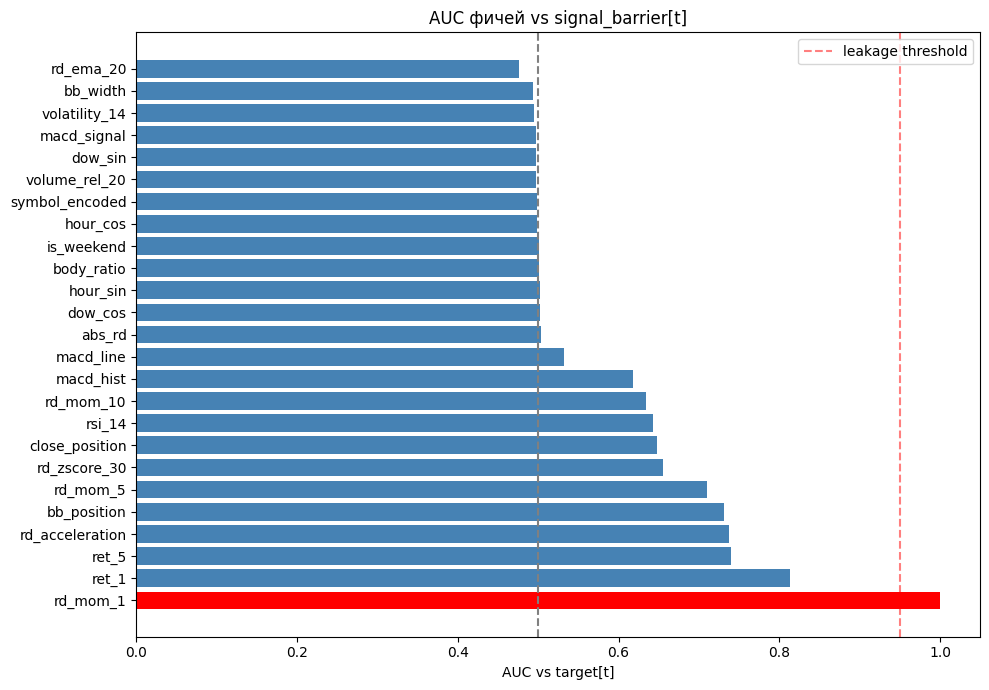

In [10]:
# AUC каждой фичи vs target[t] (для полноты)
valid_corr = df.dropna(subset=cols + ['signal_barrier'])
y_corr = (valid_corr['signal_barrier'] == 1).astype(int)

aucs = {}
for c in cols:
    if c in valid_corr.columns:
        try:
            aucs[c] = roc_auc_score(y_corr, valid_corr[c])
        except:
            aucs[c] = 0.5

auc_sorted = sorted(aucs.items(), key=lambda x: -x[1])
print('Топ-10 фичей по AUC vs target[t]:')
for name, auc in auc_sorted[:10]:
    flag = ' *** LEAKAGE' if auc > 0.95 else ''
    print(f'  {name}: {auc:.4f}{flag}')

fig, ax = plt.subplots(figsize=(10, 7))
names = [x[0] for x in auc_sorted]
values = [x[1] for x in auc_sorted]
colors = ['red' if v > 0.95 else 'steelblue' for v in values]
ax.barh(range(len(names)), values, color=colors)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.axvline(0.5, color='gray', ls='--')
ax.axvline(0.95, color='red', ls='--', alpha=0.5, label='leakage threshold')
ax.set_xlabel('AUC vs target[t]')
ax.set_title('AUC фичей vs signal_barrier[t]')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7b. H6: Горизонт is_transition (2–5 баров)

**Идея:** Вместо is_transition[t+1] (переход ровно на следующем баре) проверить «переход в ближайшие H баров»:
- is_transition_h2: переход на t+1 ИЛИ t+2
- is_transition_h3: переход в окне t+1..t+3
- is_transition_h5: переход в окне t+1..t+5

Более мягкий target может дать выше AUC: модель угадывает «переход скоро», а не «переход завтра».

In [11]:
# --- H6: is_transition в горизонте 1, 2, 3, 5 баров ---
# Цель: сравнить AUC фичей vs is_transition_h1, h2, h3, h5
df_h6 = df.copy()
df_h6['sb_next'] = df_h6.groupby('session_key')['signal_barrier'].shift(-1)

# is_transition_h1 = переход ровно на t+1
df_h6['is_trans_h1'] = ((df_h6['signal_barrier'] != df_h6['sb_next']) & df_h6['sb_next'].notna()).astype(int)

# is_transition_h2 = переход в окне t+1..t+2
for h in [2, 3, 5]:
    col = f'is_trans_h{h}'
    df_h6[col] = 0
    for k in range(1, h + 1):
        sb_k = df_h6.groupby('session_key')['signal_barrier'].shift(-k)
        df_h6[col] = df_h6[col] | ((df_h6['signal_barrier'] != sb_k) & sb_k.notna())
    df_h6[col] = df_h6[col].astype(int)

h6_features = ['ret_1', 'ret_5', 'rsi_14', 'bb_position', 'volatility_14', 'close_position', 'macd_hist', 'rd_zscore_30']
h6_targets = ['is_trans_h1', 'is_trans_h2', 'is_trans_h3', 'is_trans_h5']

print('H6: AUC фичей vs is_transition в горизонте 1–5 баров')
print(f'{"Feature":<16} ' + ''.join(f'{t:>12}' for t in h6_targets))
for feat in h6_features:
    if feat not in df_h6.columns:
        continue
    aucs = []
    for tgt in h6_targets:
        sub = df_h6.dropna(subset=[feat, tgt])
        y = sub[tgt].values
        if len(np.unique(y)) < 2:
            aucs.append(0.5)
        else:
            aucs.append(roc_auc_score(y, sub[feat]))
    print(f'{feat:<16} ' + ''.join(f'{a:>12.4f}' for a in aucs))

# Baseline (доля переходов)
for tgt in h6_targets:
    rate = df_h6[tgt].mean()
    print(f'  Baseline {tgt}: {rate*100:.1f}%')

H6: AUC фичей vs is_transition в горизонте 1–5 баров
Feature           is_trans_h1 is_trans_h2 is_trans_h3 is_trans_h5


ret_1                  0.5026      0.5029      0.5026      0.5002


ret_5                  0.4991      0.4998      0.4992      0.4980


rsi_14                 0.4986      0.4981      0.4975      0.4977


bb_position            0.4986      0.4977      0.4965      0.4947


volatility_14          0.5079      0.5143      0.5183      0.5297


close_position         0.5021      0.4995      0.4994      0.4991


macd_hist              0.4989      0.4982      0.4976      0.4973


rd_zscore_30           0.4980      0.4974      0.4956      0.4926
  Baseline is_trans_h1: 38.1%
  Baseline is_trans_h2: 61.6%
  Baseline is_trans_h3: 75.5%
  Baseline is_trans_h5: 89.5%


---
## 7c. H7: Profit-based target (прибыль >1%, просадка ≤0.5%)

**Идея:** Альтернативный target по реальной прибыльности входа (OHLC):
- **target = 1 (BUY):** Покупка на close[t] приносит >1% прибыли в горизонте H, при этом цена не падает >0.5% (min(low) ≥ close×0.995, max(high) ≥ close×1.01).
- **target = -1 (SELL):** Short на close[t] даёт >1% прибыли, при этом цена не растёт >0.5% (max(high) ≤ close×1.005, min(low) ≤ close×0.99).
- **target = 0:** Условия не выполнены.

**signal_barrier** при этом — фича (текущий режим RD), а не target.

In [12]:
# --- H7: Profit-based target (BUY/SELL приносит >1% прибыли, просадка ≤0.5%) ---
# Горизонт H баров вперёд. Используем OHLC для проверки достижимости TP/SL.
H_PROFIT = 5
PROFIT_PCT = 0.01   # 1% прибыли
DRAWDOWN_PCT = 0.005  # 0.5% макс просадка/движение против

grp = df.groupby('session_key')
# max(high) и min(low) в окне t+1..t+H
high_fwd = pd.concat([grp['high'].shift(-k) for k in range(1, H_PROFIT+1)], axis=1).max(axis=1)
low_fwd = pd.concat([grp['low'].shift(-k) for k in range(1, H_PROFIT+1)], axis=1).min(axis=1)

df_h7 = df.copy()
df_h7['high_fwd'] = high_fwd
df_h7['low_fwd'] = low_fwd
df_h7['close_t'] = df_h7['close_price']

# BUY: max_high >= close*1.01 AND min_low >= close*0.995
buy_ok = (df_h7['high_fwd'] >= df_h7['close_t'] * (1 + PROFIT_PCT)) & \
         (df_h7['low_fwd'] >= df_h7['close_t'] * (1 - DRAWDOWN_PCT))
# SELL: min_low <= close*0.99 AND max_high <= close*1.005
sell_ok = (df_h7['low_fwd'] <= df_h7['close_t'] * (1 - PROFIT_PCT)) & \
          (df_h7['high_fwd'] <= df_h7['close_t'] * (1 + DRAWDOWN_PCT))

df_h7['profit_target'] = 0
df_h7.loc[buy_ok & ~sell_ok, 'profit_target'] = 1
df_h7.loc[sell_ok & ~buy_ok, 'profit_target'] = -1
# Если оба — оставляем 0 (неоднозначно)

valid_h7 = df_h7.dropna(subset=['profit_target', 'ret_1'])
binary_h7 = (valid_h7['profit_target'] == 1).astype(int)
n_buy = (valid_h7['profit_target'] == 1).sum()
n_sell = (valid_h7['profit_target'] == -1).sum()
n_hold = (valid_h7['profit_target'] == 0).sum()
print(f'H7: Profit-based target (H={H_PROFIT}, TP={PROFIT_PCT*100}%, SL={DRAWDOWN_PCT*100}%)')
print(f'  BUY (1): {n_buy:,} ({n_buy/len(valid_h7)*100:.1f}%)')
print(f'  SELL (-1): {n_sell:,} ({n_sell/len(valid_h7)*100:.1f}%)')
print(f'  HOLD (0): {n_hold:,} ({n_hold/len(valid_h7)*100:.1f}%)')

# AUC фичей vs profit_target (бинарно: 1 vs -1, без 0)
sub_binary = valid_h7[valid_h7['profit_target'] != 0].copy()
sub_binary['y_binary'] = (sub_binary['profit_target'] == 1).astype(int)
if len(np.unique(sub_binary['y_binary'])) > 1:
    print(f'\nAUC фичей vs profit_target (1 vs -1, n={len(sub_binary):,}):')
    for feat in ['ret_1', 'ret_5', 'bb_position', 'close_position', 'rsi_14', 'volatility_14']:
        if feat in sub_binary.columns:
            s = sub_binary.dropna(subset=[feat])
            if len(np.unique(s['y_binary'])) > 1:
                auc = roc_auc_score(s['y_binary'], s[feat])
                print(f'  {feat}: {auc:.4f}')

H7: Profit-based target (H=5, TP=1.0%, SL=0.5%)
  BUY (1): 46,440 (12.7%)
  SELL (-1): 44,280 (12.2%)
  HOLD (0): 273,607 (75.1%)

AUC фичей vs profit_target (1 vs -1, n=90,720):
  ret_1: 0.4971
  ret_5: 0.5097
  bb_position: 0.5233
  close_position: 0.4895
  rsi_14: 0.5223


  volatility_14: 0.4833


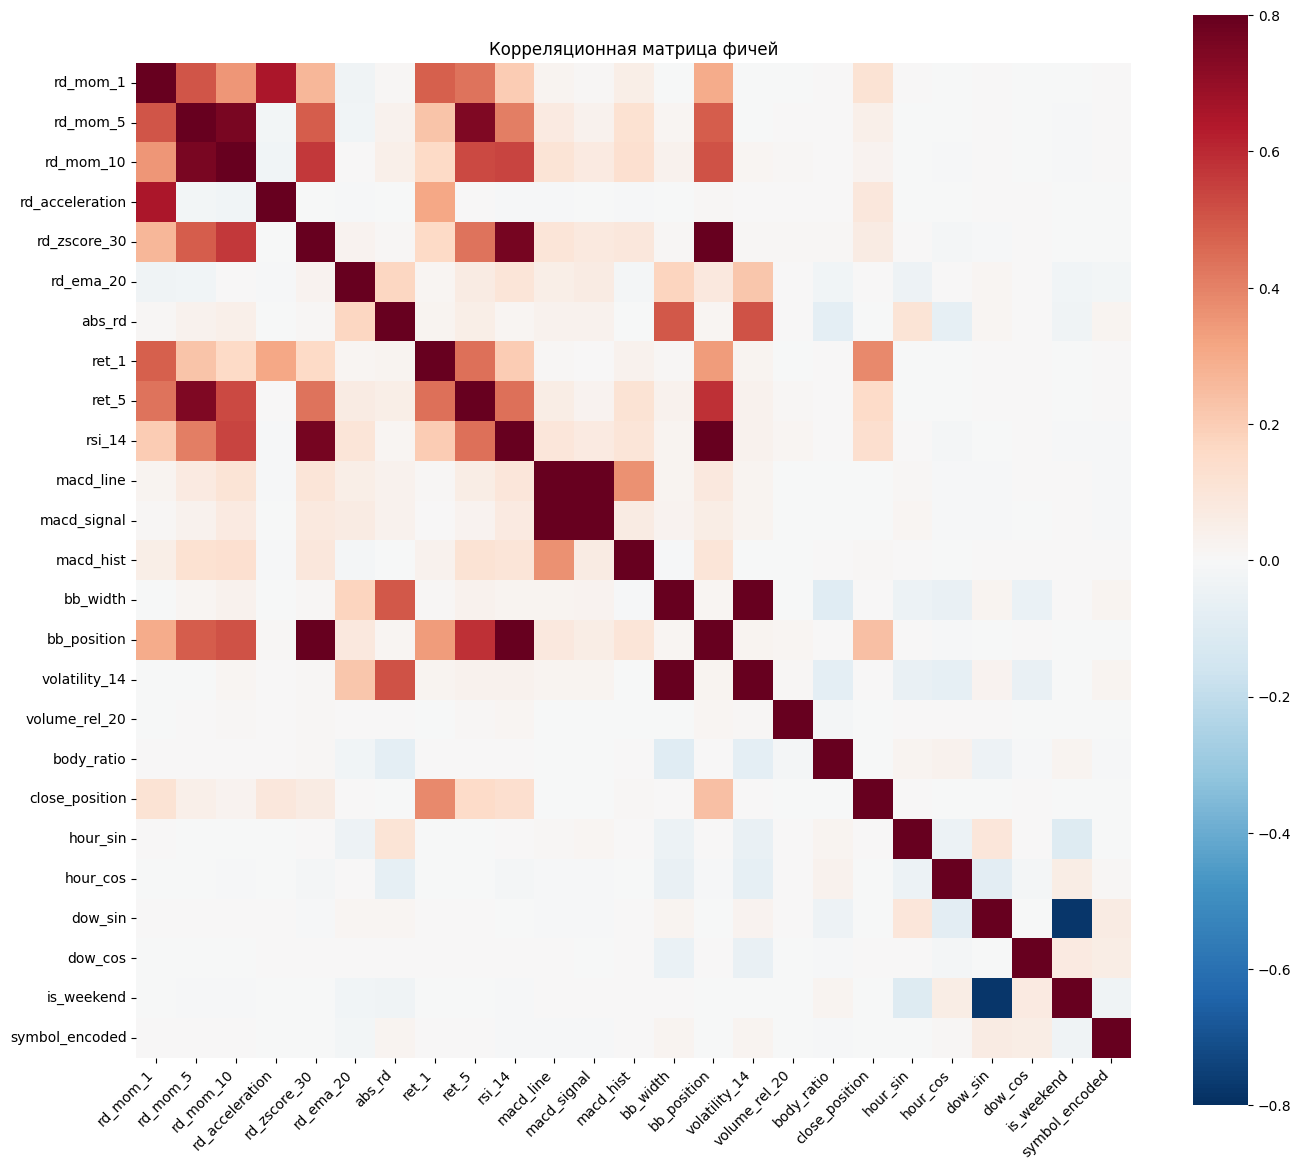

Пары с |corr| > 0.85:
  macd_line ↔ macd_signal: 0.952


In [13]:
# Корреляционная матрица
valid_cm = df.dropna(subset=cols)
corr_matrix = valid_cm[cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-0.8, vmax=0.8, square=True, ax=ax)
ax.set_title('Корреляционная матрица фичей')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Высокая корреляция
high_pairs = []
for i, c1 in enumerate(cols):
    for c2 in cols[i+1:]:
        r = corr_matrix.loc[c1, c2]
        if abs(r) > 0.85:
            high_pairs.append((c1, c2, round(r, 3)))
if high_pairs:
    print('Пары с |corr| > 0.85:')
    for c1, c2, r in sorted(high_pairs, key=lambda x: -abs(x[2])):
        print(f'  {c1} ↔ {c2}: {r}')

---
## 8. Выводы и рекомендации

### Ключевая находка: signal_barrier[t] ≡ sign(rd_mom_1[t])

**signal_barrier** в текущем датасете определяется направлением изменения rd_value:  
- Если rd_value выросло → signal_barrier = 1 (BUY / long)  
- Если rd_value упало → signal_barrier = -1 (SELL / short)  

Поэтому **rd_mom_1 — это target в числовой форме**, его AUC ≈ 1.0 — тривиально.  
Модель с rd_mom_1 как фичей бесполезна — она просто считает sign().

### Что предсказывать?

1. **target[t+1]**: режим на следующем баре. Лучшие фичи:  
   - close_position (~0.68), ret_1 (~0.67), rd_mom_1 (~0.65)

2. **is_transition[t+1]**: произойдёт ли смена режима на следующем баре.  
   - Фичи предсказывают это слабо (AUC ~0.50)

### Итоги гипотез

| # | Гипотеза | Результат |
|---|----------|----------|
| H1 | rd_mom_1 leakage | **ДА**: signal_barrier ≡ sign(rd_mom_1). Leakage by design. |
| H2 | RD предсказывает доходность | **Нет**: corr ≈ -0.01 |
| H3 | Volume spike перед сменой | **Нет**: ratio ≈ 0.99 |
| H4 | Предсказание перехода | Слабо: AUC ~0.50 |
| H5 | Волатильность влияет на AUC | **Нет**: AUC стабилен по terciles |
| H6 | Горизонт is_transition (2–5 баров) | Проверить AUC vs is_trans_h2, h3, h5 |
| H7 | Profit-based target (OHLC, TP 1%, SL 0.5%) | Альтернативный target; signal_barrier как фича |

### Рекомендации

1. **Исключить rd_mom_1, rd_mom_5, rd_mom_10** из фичей (или осознанно использовать только для target[t+1]).  
2. Уточнить с заказчиком: ML должна предсказывать target[t+1] или is_transition?  
3. Мультиколлинеарность: macd_line ↔ macd_signal (>0.95) — оставить одну или macd_hist.

---
## 9. Reality check: signal_barrier на графике цены

### Что проверяем

signal_barrier[t] = sign(rd_value[t] − rd_value[t−1]).  
Вопрос: если мы **следуем signal_barrier** и торгуем, получим ли прибыль?

### Как строится график

- **Линия цены**: зелёная = signal_barrier = 1 (long/BUY-режим), красная = signal_barrier = -1 (short/SELL-режим).  
  Каждый отрезок [bar t, bar t+1] раскрашен по значению signal_barrier[t].
- **Треугольники**: ▲ зелёный = точка перехода sb: −1 → 1 (BUY). ▼ розовый = sb: 1 → −1 (SELL).  
  Это **точки смены режима**, где, по замыслу заказчика, ML должна формировать торговый сигнал.

### Симуляция PnL

- **sb\*ret\_t (cheat)**: PnL, если на каждом баре мы УЖЕ ЗНАЕМ signal_barrier[t] и торгуем на баре t.  
  Это невозможно в реальности — signal_barrier[t] использует rd_value[t], которое становится известно только после закрытия бара t.
- **sb\*ret\_t+1 (forward)**: PnL, если мы используем signal_barrier[t] для торговли на баре t+1.  
  Это реальный forward test: решение принято на баре t, прибыль/убыток на баре t+1.
- **Buy & Hold**: просто купить в начале и держать.
- **Комиссии**: 0.06% за сделку × 2 (открытие + закрытие) × число переходов.

In [14]:
# --- 9a. Выбор длинной сессии (>= 240 баров = 4 часа) ---
sess_sizes = df.groupby('session_key').size()
long_sessions = sess_sizes[sess_sizes >= 240].sort_values(ascending=False)
print(f'Сессий >= 240 баров: {len(long_sessions)}')
print('Топ-5:')
for sk, n in long_sessions.head(5).items():
    sub = df[df['session_key'] == sk]
    sym = sub['symbol'].iloc[0]
    print(f'  {sk}: {n} баров, symbol={sym}')

Сессий >= 240 баров: 547
Топ-5:
  BIRB_s6: 2377 баров, symbol=BIRB
  UAI_s3: 1998 баров, symbol=UAI
  ARC_s1: 1898 баров, symbol=ARC
  ZIL_s1: 1897 баров, symbol=ZIL
  ROAM_s4: 1677 баров, symbol=ROAM


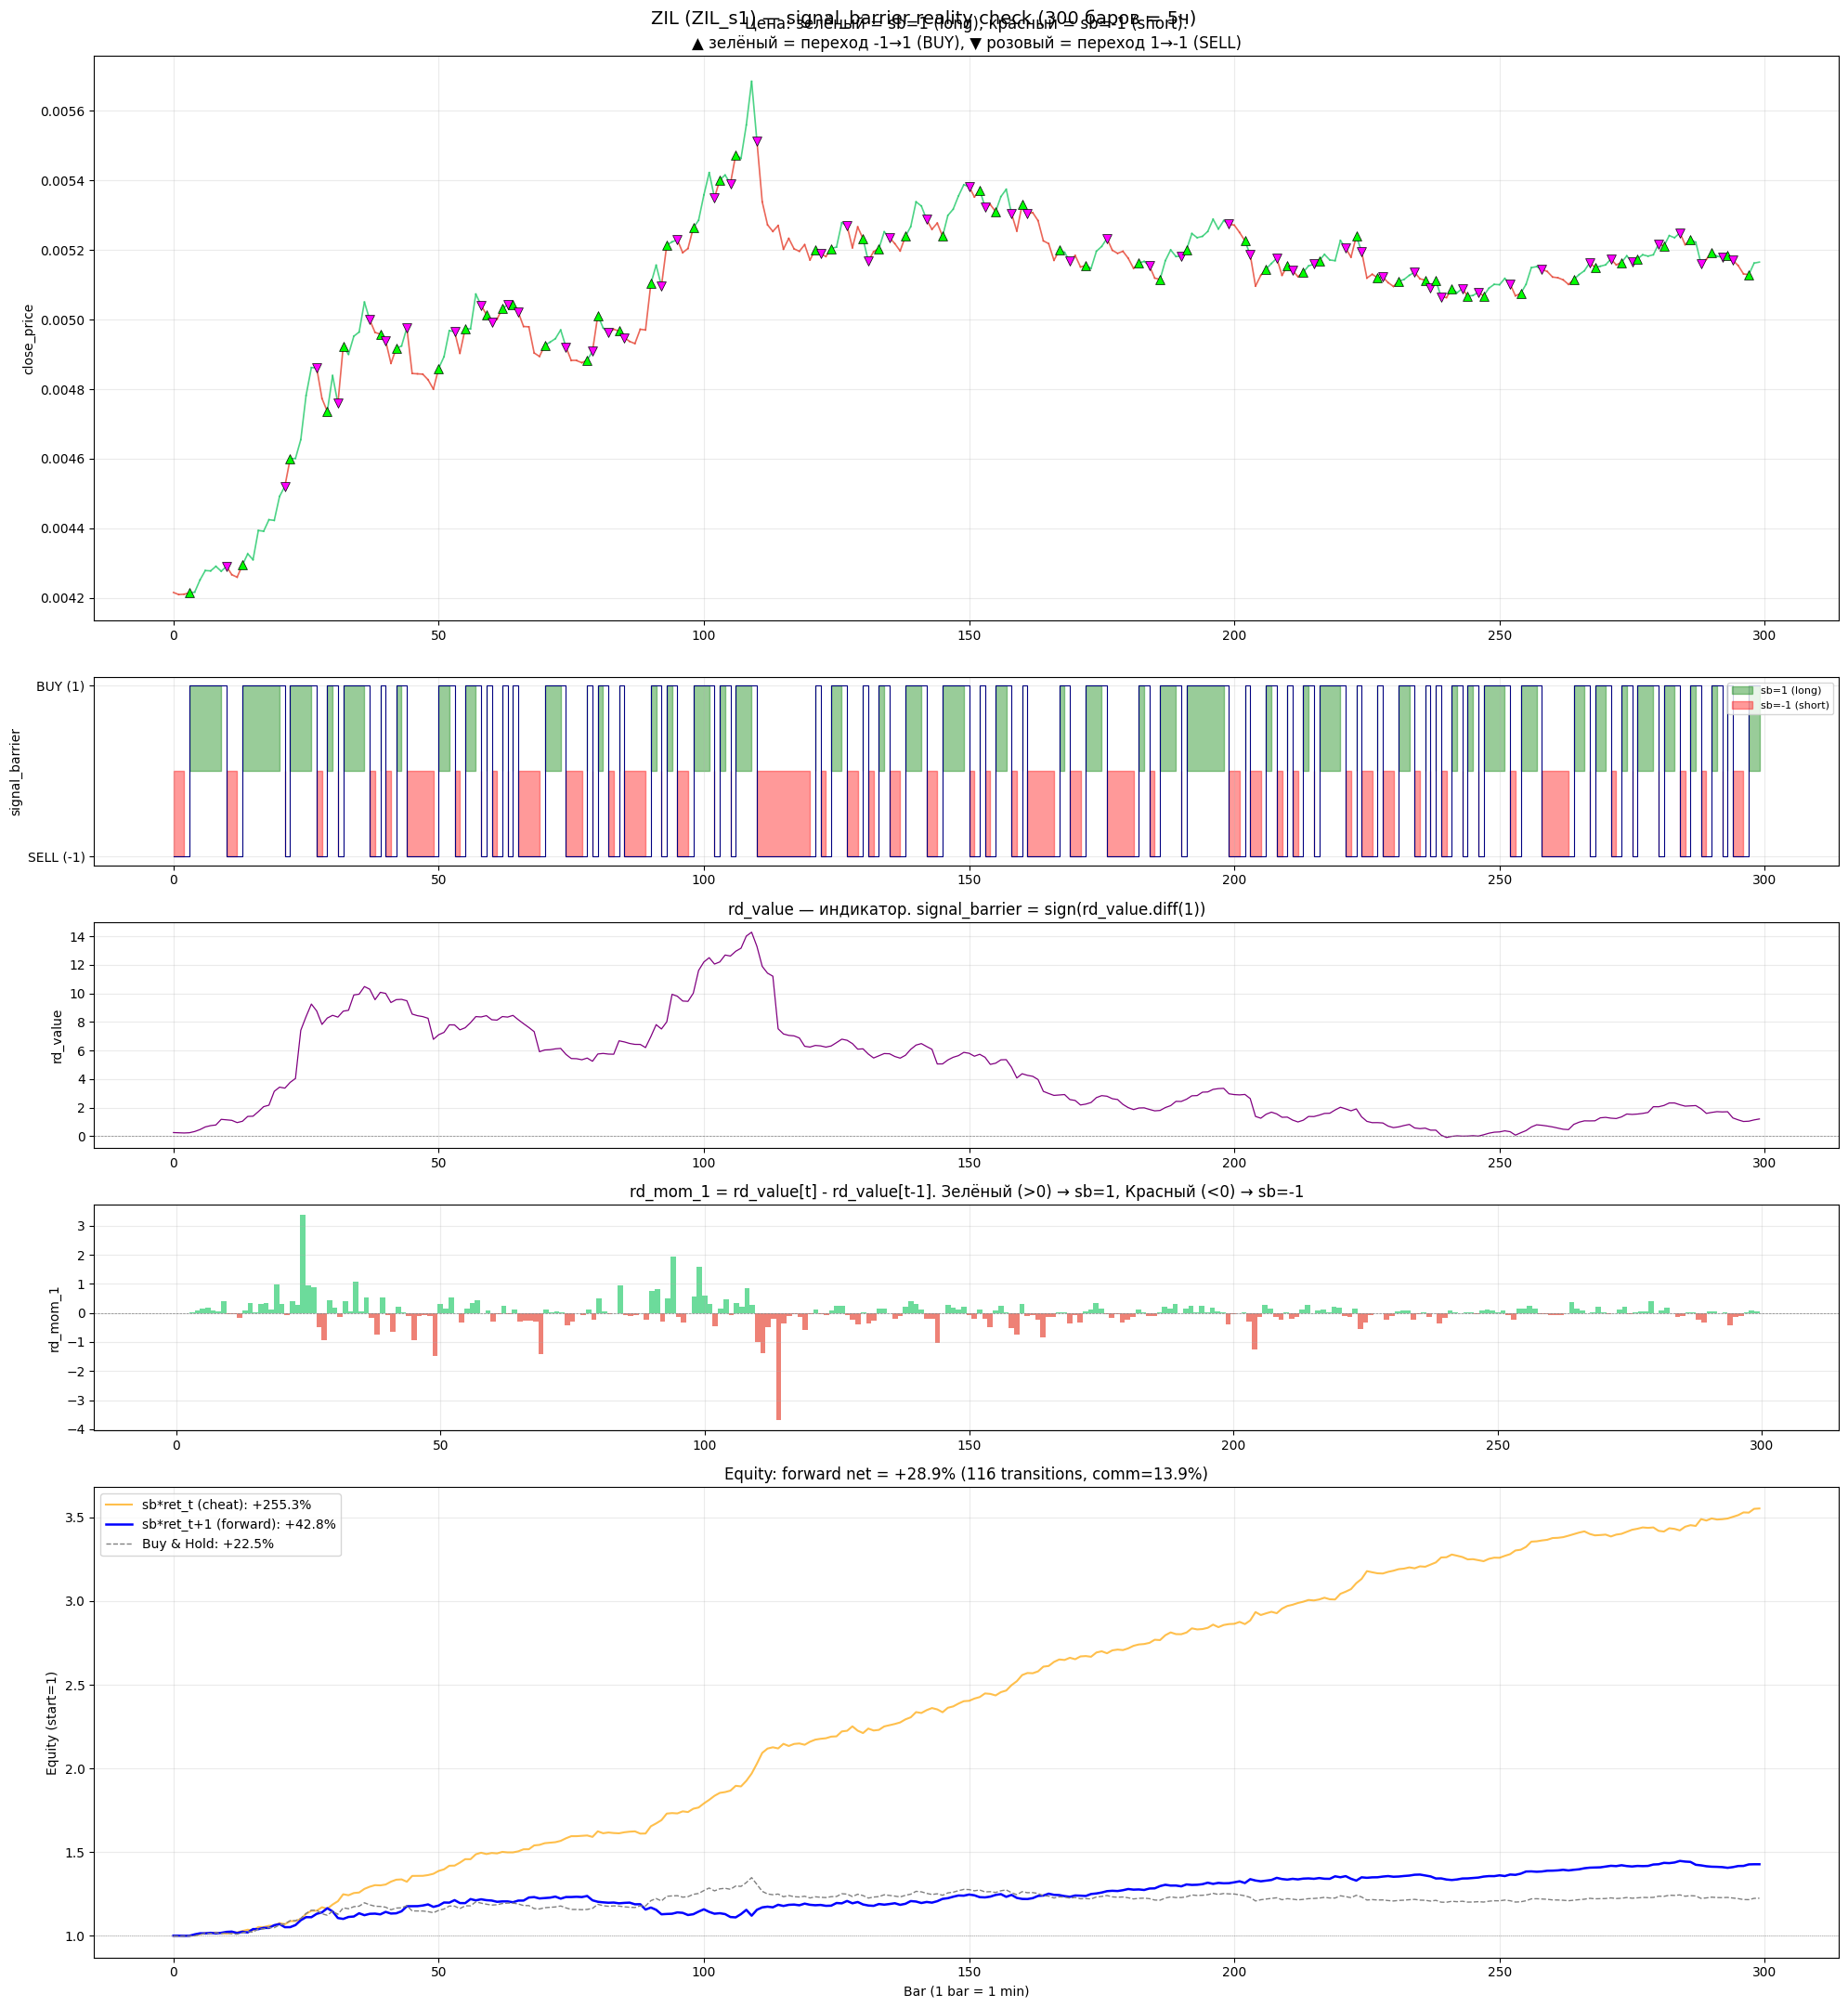

In [15]:
# --- 9b. График: цена + signal_barrier + rd_value + rd_mom_1 + equity ---
SESSION_KEY = 'ZIL_s1'
WINDOW = 300
COMMISSION = 0.0006

one = df[df['session_key'] == SESSION_KEY].copy().reset_index(drop=True).iloc[:WINDOW]
sym = one['symbol'].iloc[0]

one['ret_this'] = one['close_price'].pct_change()
one['ret_next'] = one['close_price'].pct_change().shift(-1)
one['pnl_cheat'] = one['signal_barrier'] * one['ret_this']
one['pnl_real'] = one['signal_barrier'] * one['ret_next']
one['eq_cheat'] = (1 + one['pnl_cheat'].fillna(0)).cumprod()
one['eq_real'] = (1 + one['pnl_real'].fillna(0)).cumprod()
one['signal_prev'] = one['signal_barrier'].shift(1)
one['is_transition'] = one['signal_barrier'] != one['signal_prev']

fig, axes = plt.subplots(5, 1, figsize=(20, 22),
                         gridspec_kw={'height_ratios': [3, 1, 1.2, 1.2, 2.5]})
fig.suptitle(f'{sym} ({SESSION_KEY}) — signal_barrier reality check ({WINDOW} баров = {WINDOW//60}ч)',
             fontsize=14, y=0.98)

# (1) Цена + signal_barrier цвет + переходы
ax = axes[0]
for i in range(len(one) - 1):
    c = '#2ecc71' if one['signal_barrier'].iloc[i] == 1 else '#e74c3c'
    ax.plot([i, i+1], [one['close_price'].iloc[i], one['close_price'].iloc[i+1]],
            color=c, linewidth=1.2, alpha=0.85)
trans_idx = one[one['is_transition'] & (one.index > 0)].index
for idx in trans_idx:
    sb = one['signal_barrier'].iloc[idx]
    marker = '^' if sb == 1 else 'v'
    clr = 'lime' if sb == 1 else 'magenta'
    ax.scatter(idx, one['close_price'].iloc[idx], marker=marker, color=clr,
               s=50, zorder=5, edgecolors='black', linewidths=0.5)
ax.set_ylabel('close_price')
ax.set_title('Цена: зелёный = sb=1 (long), красный = sb=-1 (short).\n'
             '▲ зелёный = переход -1→1 (BUY), ▼ розовый = переход 1→-1 (SELL)')
ax.grid(alpha=0.25)

# (2) signal_barrier напрямую
ax = axes[1]
ax.fill_between(range(len(one)), one['signal_barrier'], step='post', alpha=0.4,
                color='green', where=one['signal_barrier'] == 1, label='sb=1 (long)')
ax.fill_between(range(len(one)), one['signal_barrier'], step='post', alpha=0.4,
                color='red', where=one['signal_barrier'] == -1, label='sb=-1 (short)')
ax.step(range(len(one)), one['signal_barrier'], where='post', color='navy', linewidth=0.8)
ax.set_ylabel('signal_barrier')
ax.set_yticks([-1, 1])
ax.set_yticklabels(['SELL (-1)', 'BUY (1)'])
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.25)

# (3) rd_value
ax = axes[2]
ax.plot(range(len(one)), one['rd_value'], color='purple', linewidth=0.9)
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_ylabel('rd_value')
ax.set_title('rd_value — индикатор. signal_barrier = sign(rd_value.diff(1))')
ax.grid(alpha=0.25)

# (4) rd_mom_1 = rd_value.diff(1). sign(rd_mom_1) == signal_barrier
ax = axes[3]
colors_bar = ['#2ecc71' if v > 0 else '#e74c3c' for v in one['rd_mom_1'].fillna(0)]
ax.bar(range(len(one)), one['rd_mom_1'].fillna(0), color=colors_bar, alpha=0.7, width=1)
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_ylabel('rd_mom_1')
ax.set_title('rd_mom_1 = rd_value[t] - rd_value[t-1]. Зелёный (>0) → sb=1, Красный (<0) → sb=-1')
ax.grid(alpha=0.25)

# (5) Equity
ax = axes[4]
bh = one['close_price'] / one['close_price'].iloc[0]
n_trans = one['is_transition'].sum()
comm_total = n_trans * 2 * COMMISSION
pnl_cheat_total = (one['eq_cheat'].iloc[-1] - 1) * 100
pnl_real_total = (one['eq_real'].iloc[-2] - 1) * 100
pnl_net = pnl_real_total - comm_total * 100

ax.plot(range(len(one)), one['eq_cheat'],
        label=f'sb*ret_t (cheat): {pnl_cheat_total:+.1f}%', color='orange', linewidth=1.5, alpha=0.7)
ax.plot(range(len(one)), one['eq_real'],
        label=f'sb*ret_t+1 (forward): {pnl_real_total:+.1f}%', color='blue', linewidth=1.8)
ax.plot(range(len(one)), bh,
        label=f'Buy & Hold: {(bh.iloc[-1]-1)*100:+.1f}%', color='gray', linewidth=1, ls='--')
ax.axhline(1, color='gray', ls=':', lw=0.5)
ax.set_ylabel('Equity (start=1)')
ax.set_xlabel('Bar (1 bar = 1 min)')
ax.set_title(f'Equity: forward net = {pnl_net:+.1f}% ({n_trans} transitions, comm={comm_total*100:.1f}%)')
ax.legend(loc='upper left')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [16]:
# --- 9c. PnL по signal_barrier на 10 длинных сессиях ---
COMMISSION = 0.0006
long_keys = df.groupby('session_key').size()
long_keys = long_keys[long_keys >= 240].sort_values(ascending=False).head(10).index

rows_pnl = []
for sk in long_keys:
    s = df[df['session_key'] == sk].copy().reset_index(drop=True).iloc[:240]
    s['ret_this'] = s['close_price'].pct_change()
    s['ret_next'] = s['close_price'].pct_change().shift(-1)
    eq_cheat = (1 + (s['signal_barrier'] * s['ret_this']).fillna(0)).cumprod()
    eq_real = (1 + (s['signal_barrier'] * s['ret_next']).fillna(0)).cumprod()
    n_tr = (s['signal_barrier'] != s['signal_barrier'].shift(1)).sum()
    comm = n_tr * 2 * COMMISSION
    pnl_cheat = (eq_cheat.iloc[-1] - 1) * 100
    pnl_real = (eq_real.iloc[-2] - 1) * 100
    pnl_net = pnl_real - comm * 100
    bh = (s['close_price'].iloc[-1] / s['close_price'].iloc[0] - 1) * 100
    sym = s['symbol'].iloc[0]
    rows_pnl.append({
        'session': sk, 'symbol': sym, 'transitions': n_tr,
        'sb*ret_t (cheat)': f'{pnl_cheat:+.1f}%',
        'sb*ret_t+1 (forward)': f'{pnl_real:+.1f}%',
        'net (−comm)': f'{pnl_net:+.1f}%',
        'Buy&Hold': f'{bh:+.1f}%',
    })

pnl_table = pd.DataFrame(rows_pnl)
print('PnL при торговле по signal_barrier — 10 длинных сессий (240 баров = 4 часа):')
print(pnl_table.to_string(index=False))

PnL при торговле по signal_barrier — 10 длинных сессий (240 баров = 4 часа):
  session symbol  transitions sb*ret_t (cheat) sb*ret_t+1 (forward) net (−comm) Buy&Hold
  BIRB_s6   BIRB           83           +51.0%               +12.3%       +2.3%    +2.8%
   UAI_s3    UAI           96          +150.4%                -1.8%      -13.3%    +4.1%
   ARC_s1    ARC           80           +62.6%               +46.9%      +37.3%   +16.4%
   ZIL_s1    ZIL           91          +226.1%               +34.3%      +23.4%   +20.1%
  ROAM_s4   ROAM           73           +46.1%               +28.1%      +19.3%    +6.1%
RIVER_s11  RIVER          103          +164.6%               +29.2%      +16.9%    -8.8%
    OG_s0     OG           86           +30.0%                +2.4%       -7.9%    -0.8%
  MERL_s6   MERL           95          +117.4%               +24.0%      +12.6%   +12.7%
   C98_s8    C98           84          +140.7%               +38.5%      +28.4%    +4.8%
  ZAMA_s0   ZAMA           92    

### Вывод по секции 9

**signal_barrier — это не «купишь тут и получишь прибыль».** Это sign(rd_value.diff(1)) — описание, куда двигался индикатор RD на текущем баре.

Однако за счёт **инерции (автокорреляции)** rd_value есть forward-value:
- Если rd рос на баре t (sb=1), с повышенной вероятностью продолжит расти на t+1.
- На 8 из 10 сессий forward PnL положительный даже после вычета комиссий.
- Но: ~80–100 переходов за 4 часа → комиссии 10–14%, что съедает значительную часть прибыли.

**Вывод для ML:**
1. Задача модели — предсказать `signal_barrier[t+1]` (= sign(rd_mom_1[t+1])), используя фичи на баре t.
2. rd_mom_1 на баре t — это target[t], а не фича. Его нельзя использовать для предсказания target[t].
3. Для предсказания target[t+1] лучшие фичи: close_position (0.685), ret_1 (0.674), bb_position (0.596).